In [2]:
# imports
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# set which one-hot sample to compare (0-4)
# 0: corner (0,0)
# 1: corner (47,47)
# 2: center (24,24)
# 3: top edge (0,24)
# 4: left edge (24,0)
TEST_NUM = 1

In [4]:
def load_rtl_layer(path, nfrac):
    raw = np.loadtxt(path, delimiter=',')   # shape (n_positions, n_channels)
    flat = raw.flatten()                     # row-major: channel varies fastest, matches (H,W,C) flatten
    return flat / (2 ** nfrac)

def load_ref_layer(path):
    return np.loadtxt(path, delimiter=',')   # already flat, already decimal

# every layer in pipeline order:
#   (short name, rtl filename suffix, hls4ml filename suffix, nfrac)
LAYER_SPECS = [
    ("conv0",  "conv0",  "q_activation",    6),
    ("pool0",  "pool0",  "max_pooling2d",   6),
    ("conv1",  "conv1",  "q_activation_1",  5),
    ("pool1",  "pool1",  "max_pooling2d_1", 5),
    ("conv2",  "conv2",  "q_activation_2",  5),
    ("pool2",  "pool2",  "max_pooling2d_2", 5),
    ("dense0", "dense0", "q_dense",         5),
    ("relu0",  "relu0",  "q_activation_3",  5),
    ("dense1", "dense1", "q_dense_1",       5),
    ("relu1",  "relu1",  "q_activation_4",  5),
    ("final",  "final",  "q_dense_2",       5),
]

def rtl_path(test_num, suffix):
    return f"round_up_traces/rtl_{test_num}_{suffix}.csv"

def hls_path(test_num, suffix):
    return f"traces/hls4ml_{test_num}_{suffix}.csv"

def keras_path(test_num, suffix):
    return f"traces/keras_{test_num}_{suffix}.csv"

In [ ]:
def diff_stats(rtl_p, ref_p, nfrac, label=None, outlier_threshold=0.1):
    rtl = load_rtl_layer(rtl_p, nfrac)
    ref = load_ref_layer(ref_p)
    n = min(len(rtl), len(ref))
    diff = np.abs(rtl[:n] - ref[:n])
    stats = {
        "label": label or ref_p, "mean": diff.mean(), "median": np.median(diff),
        "p95": np.percentile(diff, 95), "max": diff.max(),
        "outliers": int((diff > outlier_threshold).sum()), "n": diff.size,
    }
    print(f"{stats['label']:12s} mean={stats['mean']:.6f} median={stats['median']:.6f} "
          f"p95={stats['p95']:.6f} max={stats['max']:.6f} outliers={stats['outliers']}/{stats['n']} (>{outlier_threshold})")
    return stats

def run_full_comparison(test_num, ref_source="hls4ml"):
    print(f"=== TEST_NUM={test_num} ===")
    results = []
    for name, rtl_suffix, hls_suffix, nfrac in LAYER_SPECS:
        results.append(diff_stats(rtl_path(test_num, rtl_suffix), hls_path(test_num, hls_suffix), nfrac, label=name))
    return results

In [32]:
import contextlib
import io

buf = io.StringIO()

with contextlib.redirect_stdout(buf):
    results_by_test = {}
    for test_num in range(5):
        results_by_test[test_num] = run_full_comparison(test_num)

# attach ULP figures using each layer's own nfrac (quantization step size)
nfrac_by_label = {name: nfrac for name, _, _, nfrac in LAYER_SPECS}
for results in results_by_test.values():
    for r in results:
        nfrac = nfrac_by_label[r["label"]]
        r["max_ulp"] = r["max"] * (2 ** nfrac)
        r["mean_ulp"] = r["mean"] * (2 ** nfrac)

positions = {
    0: "Corner (0,0)",
    1: "Corner (47,47)",
    2: "Center (24,24)",
    3: "Top edge (0,24)",
    4: "Left edge (24,0)",
}

OUTLIER_THRESHOLD = 0.1  # must match the threshold used in diff_stats/run_full_comparison
outlier_col = f"Outliers(>{OUTLIER_THRESHOLD})"

lines = []
lines.append("RTL vs. HLS4ML Comparison")
lines.append("-" * 70)
lines.append("")
lines.append("Final Output Layer: All Test Positions")
lines.append("-" * 70)
lines.append(f"{'Test Position':<20}{'Mean Err':>10}{'Mean(ULP)':>11}{'Max Err':>10}{'Max(ULP)':>10}{outlier_col:>16}")
for test_num, results in results_by_test.items():
    f = results[-1]
    pos_label = positions.get(test_num, f"Test {test_num}")
    lines.append(f"{pos_label:<20}{f['mean']:>10.6f}{f['mean_ulp']:>11.2f}{f['max']:>10.6f}{f['max_ulp']:>10.2f}{f['outliers']:>13d}/{f['n']}")

# per-layer breakdown for EVERY test position, not just one
for test_num, results in results_by_test.items():
    pos_label = positions.get(test_num, f"Test {test_num}")
    lines.append("")
    lines.append(f"Per-Layer Breakdown (Test {test_num}: {pos_label})")
    lines.append("-" * 70)
    lines.append(f"{'Layer':<12}{'Mean Err':>10}{'Mean(ULP)':>11}{'Max Err':>10}{'Max(ULP)':>10}{outlier_col:>16}")
    for r in results:
        lines.append(f"{r['label']:<12}{r['mean']:>10.6f}{r['mean_ulp']:>11.2f}{r['max']:>10.6f}{r['max_ulp']:>10.2f}{r['outliers']:>13d}/{r['n']}")

report_text = "\n".join(lines)
print(report_text)

with open("/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/python/final_results_summary.txt", "w") as f:
    f.write(report_text)

RTL vs. HLS4ML Comparison
----------------------------------------------------------------------

Final Output Layer: All Test Positions
----------------------------------------------------------------------
Test Position         Mean Err  Mean(ULP)   Max Err  Max(ULP)  Outliers(>0.1)
Corner (0,0)          0.012500       0.40  0.031250      1.00            0/5
Corner (47,47)        0.012500       0.40  0.031250      1.00            0/5
Center (24,24)        0.018750       0.60  0.062500      2.00            0/5
Top edge (0,24)       0.012500       0.40  0.031250      1.00            0/5
Left edge (24,0)      0.050000       1.60  0.093750      3.00            0/5

Per-Layer Breakdown (Test 0: Corner (0,0))
----------------------------------------------------------------------
Layer         Mean Err  Mean(ULP)   Max Err  Max(ULP)  Outliers(>0.1)
conv0         0.000002       0.00  0.015625      1.00            0/12684
pool0         0.000043       0.00  0.015625      1.00            0/726


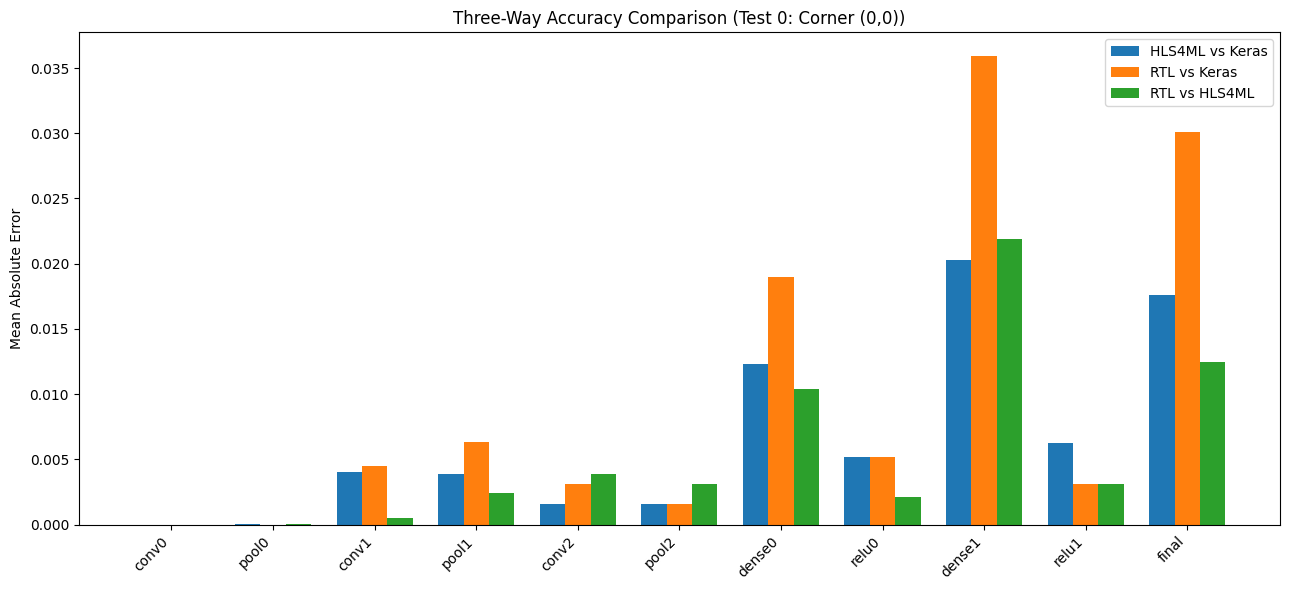

In [34]:
def plot_three_way_comparison(test_num):
    # gather all three comparisons for this test
    hls_vs_keras = []
    rtl_vs_keras = []
    rtl_vs_hls = []

    for name, rtl_suffix, hls_suffix, nfrac in LAYER_SPECS:
        rtl = load_rtl_layer(rtl_path(test_num, rtl_suffix), nfrac)
        hls = load_ref_layer(hls_path(test_num, hls_suffix))
        keras = load_ref_layer(keras_path(test_num, hls_suffix))

        n = min(len(rtl), len(hls), len(keras))
        hls_vs_keras.append(np.abs(hls[:n] - keras[:n]).mean())
        rtl_vs_keras.append(np.abs(rtl[:n] - keras[:n]).mean())
        rtl_vs_hls.append(np.abs(rtl[:n] - hls[:n]).mean())

    names = [name for name, _, _, _ in LAYER_SPECS]
    x = np.arange(len(names))
    width = 0.25

    plt.figure(figsize=(13, 6))
    plt.bar(x - width, hls_vs_keras, width, label='HLS4ML vs Keras')
    plt.bar(x, rtl_vs_keras, width, label='RTL vs Keras')
    plt.bar(x + width, rtl_vs_hls, width, label='RTL vs HLS4ML')
    plt.xticks(x, names, rotation=45, ha='right')
    plt.ylabel('Mean Absolute Error')
    plt.title(f'Three-Way Accuracy Comparison (Test {test_num}: {positions.get(test_num, "")})')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_three_way_comparison(0)  # or whichever test you want to show